In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, f1_score, recall_score, average_precision_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


## 1) Loading + basic cleaning

In [2]:
df = pd.read_csv("/content/data_clean (2).csv", parse_dates=["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

# Fix your column spellings (your cleaned file removed degree symbol)
# (Optional) Rename to ML-friendly names
rename_map = {
    "Temperature, C": "Temp_C",
    "Humidity, %": "RH_pct",
    "Illumination, lx": "Lux",
    "CO, ppm": "CO_ppm",              # If this is actually CO2, rename to CO2_ppm
    "Pressure, MPa": "Pressure_MPa",
    "Solution temperature, C": "SolTemp_C",
    "Solution acidity, pH": "pH",
    "Solution conductivity, S/cm": "Cond_Scm",
    "Battery, V": "Battery_V",
    "Air circulation": "Air_circulation",
    "Vcc, V": "Vcc_V",
}
df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})

df.head()


,Timestamp,Temp_C,RH_pct,Lux,CO_ppm,Pressure_MPa,SolTemp_C,pH,Cond_Scm,Heater,...,Air_circulation,Ground,Fog,Pump 1,Pump 2,Valve 1,Valve 2,Battery_V,Vcc_V,Version
0,2025-05-17 12:49:00,26.7,74,5855,1394.0,0.315,13.8,7.0,406,0,...,0,0,0,1,0,0,0,4.068,11.946,2.6/1.8
1,2025-05-17 12:50:00,27.4,74,6828,1402.0,0.314,14.2,7.0,408,0,...,0,0,0,0,0,0,0,4.068,11.946,2.6/1.8
2,2025-05-17 12:51:00,28.1,73,6802,1397.0,0.010,14.2,7.0,408,0,...,0,0,1,0,0,0,0,4.068,11.964,2.6/1.8
3,2025-05-17 12:52:00,28.4,72,6760,1387.0,0.010,14.3,7.0,404,0,...,0,0,1,0,0,0,0,4.068,11.946,2.6/1.8
4,2025-05-17 12:53:00,29.0,71,9205,1397.0,0.010,14.1,7.0,409,0,...,0,0,1,1,0,0,0,4.068,11.942,2.6/1.8


## 2) Feature set + targets

In [3]:
target_cols = ["Lighting", "Ventilation", "Air_circulation", "Heater", "Fog"]

# Sensor inputs (exclude Timestamp, targets, and Version)
drop_cols = ["Timestamp", "Version"] + target_cols
X_cols = [c for c in df.columns if c not in drop_cols]

print("X_cols:", X_cols)
print("Targets:", target_cols)


X_cols: ['Temp_C', 'RH_pct', 'Lux', 'CO_ppm', 'Pressure_MPa', 'SolTemp_C', 'pH', 'Cond_Scm', 'Ground', 'Pump 1', 'Pump 2', 'Valve 1', 'Valve 2', 'Battery_V', 'Vcc_V']
Targets: ['Lighting', 'Ventilation', 'Air_circulation', 'Heater', 'Fog']


## 3) Adding VPD

In [4]:
# VPD in kPa from Temp_C and RH_pct
# (Only if these exist)
if "Temp_C" in df.columns and "RH_pct" in df.columns:
    T = df["Temp_C"].astype(float)
    RH = df["RH_pct"].astype(float)
    svp = 0.6108 * np.exp((17.27 * T) / (T + 237.3))
    df["VPD_kPa"] = svp * (1 - RH/100.0)
    if "VPD_kPa" not in X_cols:
        X_cols.append("VPD_kPa")

df[["Temp_C","RH_pct","VPD_kPa"]].head()


,Temp_C,RH_pct,VPD_kPa
0,26.7,74,0.910798
1,27.4,74,0.948966
2,28.1,73,1.026539
3,28.4,72,1.083282
4,29.0,71,1.161647


In [5]:
#target variable(s), total samples, and number of classes

print("Target variable(s):", target_cols)
print("Number of target variables:", len(target_cols))
print("Total number of samples in dataset:", len(df))
print("Number of classes per target: 2 (0 = Off, 1 = On)")

Target variable(s): ['Lighting', 'Ventilation', 'Air_circulation', 'Heater', 'Fog']
Number of target variables: 5
Total number of samples in dataset: 30227
Number of classes per target: 2 (0 = Off, 1 = On)


In [6]:
#samples distribution per class for each target
class_dist = {}
for col in target_cols:
    counts = df[col].value_counts().sort_index()
    class_dist[col] = counts
    print(f"\nTarget: {col}")
    print(counts.rename(index={0: "Class 0", 1: "Class 1"}))
class_dist_df = pd.DataFrame(class_dist).fillna(0).astype(int).T
class_dist_df.columns = [f"Class_{c}" for c in class_dist_df.columns]
class_dist_df


Target: Lighting
Lighting
Class 0    24534
Class 1     5693
Name: count, dtype: int64

Target: Ventilation
Ventilation
Class 0    30227
Name: count, dtype: int64

Target: Air_circulation
Air_circulation
Class 0    30227
Name: count, dtype: int64

Target: Heater
Heater
Class 0    30227
Name: count, dtype: int64

Target: Fog
Fog
Class 0    15639
Class 1    14588
Name: count, dtype: int64


,Class_0,Class_1
Lighting,24534,5693
Ventilation,30227,0
Air_circulation,30227,0
Heater,30227,0
Fog,15639,14588


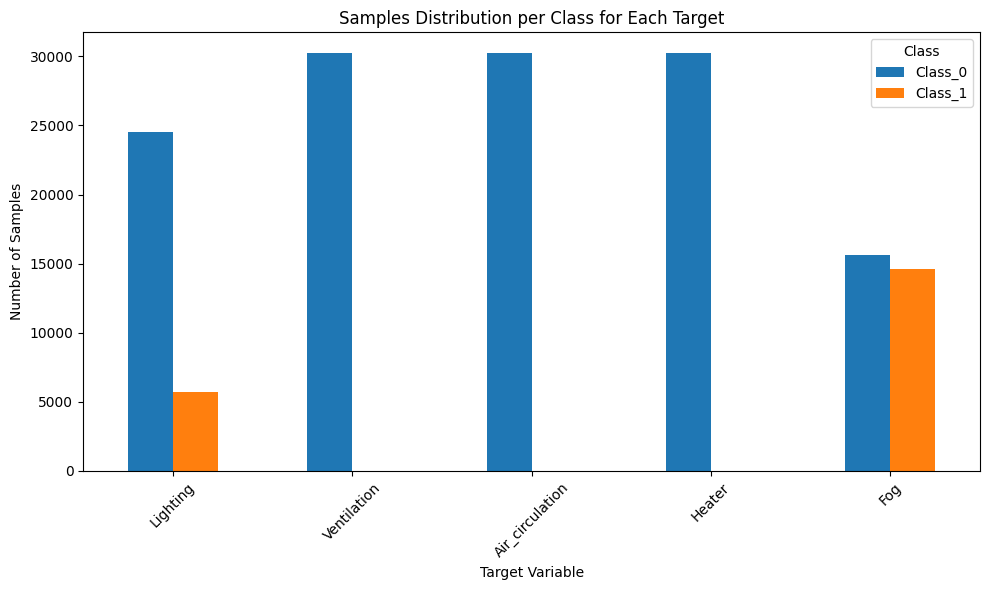

In [7]:
# bar chart of the samples distribution per class for each target

import matplotlib.pyplot as plt

class_dist_df.plot(kind="bar", figsize=(10, 6))
plt.title("Samples Distribution per Class for Each Target")
plt.xlabel("Target Variable")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [8]:
# descriptive statistics table for input features only

feature_stats = df[X_cols].describe().T
feature_stats

,count,mean,std,min,25%,50%,75%,max
Temp_C,30227.0,25.700906,9.225051,10.600,17.600000,23.900000,34.400000,48.800000
RH_pct,30227.0,73.145069,22.104715,31.000,51.000000,75.000000,96.000000,100.000000
Lux,30227.0,5290.662983,6743.654879,0.000,0.000000,1657.000000,9193.500000,26316.000000
CO_ppm,30146.0,1460.631626,153.060279,865.000,1405.000000,1499.000000,1561.000000,1732.000000
Pressure_MPa,30227.0,0.748474,6.549705,0.000,0.011000,0.013000,0.171000,65.535000
SolTemp_C,30227.0,15.492847,2.446919,9.200,13.800000,15.400000,17.200000,22.500000
pH,30227.0,6.222632,0.591660,3.600,5.800000,6.300000,6.800000,7.200000
Cond_Scm,30227.0,391.302577,17.450195,330.000,381.000000,395.000000,404.000000,426.000000
Ground,30227.0,0.309293,0.462210,0.000,0.000000,0.000000,1.000000,1.000000
Pump 1,30227.0,0.345717,0.475609,0.000,0.000000,0.000000,1.000000,1.000000


## 4) Building sequences (horizon=5)

In [9]:
def make_sequences(df, X_cols, y_cols, seq_len=30, horizon=5):
    X = df[X_cols].astype(float).to_numpy()
    Y = df[y_cols].astype(int).to_numpy()

    # Before make_sequences(...)
    df[X_cols] = df[X_cols].astype(float)

    # time-series friendly imputation
    df[X_cols] = df[X_cols].ffill().bfill()

    # final safety: fill any remaining with median
    df[X_cols] = df[X_cols].fillna(df[X_cols].median(numeric_only=True))


    n = len(df)
    # last usable input window ends at t, label taken at t+horizon
    last_t = n - 1 - horizon
    X_seq, Y_out, ts = [], [], []

    for t in range(seq_len-1, last_t+1):
        X_seq.append(X[t-seq_len+1:t+1])
        Y_out.append(Y[t+horizon])
        ts.append(df["Timestamp"].iloc[t+horizon])

    return np.asarray(X_seq), np.asarray(Y_out), pd.to_datetime(ts)

SEQ_LEN = 30     # last 30 minutes (if 1-min sampling)
HORIZON = 5      # predict action 5 minutes ahead

X_seq, Y, y_ts = make_sequences(df, X_cols, target_cols, seq_len=SEQ_LEN, horizon=HORIZON)
print(X_seq.shape, Y.shape, y_ts.min(), y_ts.max())


(30193, 30, 16) (30193, 5) 2025-05-17 13:23:00 2025-06-08 13:12:00


In [10]:
# same class distribution, but for the sequenced labels Y

print("Total number of sequenced samples:", len(Y))

for i, col in enumerate(target_cols):
    vals, counts = np.unique(Y[:, i], return_counts=True)
    print(f"\nTarget: {col}")
    for v, c in zip(vals, counts):
        print(f"Class {v}: {c}")

Total number of sequenced samples: 30193

Target: Lighting
Class 0: 24500
Class 1: 5693

Target: Ventilation
Class 0: 30193

Target: Air_circulation
Class 0: 30193

Target: Heater
Class 0: 30193

Target: Fog
Class 0: 15637
Class 1: 14556


## 5) Time-based split

In [11]:
n = len(X_seq)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X_seq[:train_end], Y[:train_end]
X_val,   y_val   = X_seq[train_end:val_end], Y[train_end:val_end]
X_test,  y_test  = X_seq[val_end:], Y[val_end:]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)


Train/Val/Test: (21135, 30, 16) (4529, 30, 16) (4529, 30, 16)


## 6) Scaling features

In [12]:
scaler = StandardScaler()

# Fit on train flattened over time
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_flat)

def scale_3d(X):
    Xf = X.reshape(-1, X.shape[-1])
    Xs = scaler.transform(Xf)
    return Xs.reshape(X.shape)

X_train_s = scale_3d(X_train)
X_val_s   = scale_3d(X_val)
X_test_s  = scale_3d(X_test)


In [13]:
def check_nan(name, arr):
    print(name, "shape", arr.shape,
          "nan:", np.isnan(arr).any(),
          "inf:", np.isinf(arr).any())

check_nan("X_train_s", X_train_s)
check_nan("X_val_s", X_val_s)
check_nan("X_test_s", X_test_s)


X_train_s shape (21135, 30, 16) nan: False inf: False
X_val_s shape (4529, 30, 16) nan: True inf: False
X_test_s shape (4529, 30, 16) nan: True inf: False


## 7) Per-actuator pos weights to handle imbalance

In [14]:
def make_sample_weights(y_2d):
    # y_2d shape: (N, num_tasks)
    weights = {}
    for i, name in enumerate(target_cols):
        y = y_2d[:, i]
        pos = (y == 1).sum()
        neg = (y == 0).sum()
        # avoid divide by zero
        w_pos = (neg / max(pos, 1.0))
        w = np.where(y == 1, w_pos, 1.0).astype("float32")
        weights[name] = w
        print(f"{name}: pos={pos} neg={neg} pos_weight~{w_pos:.2f}")
    return weights

# Keras wants y as dict if outputs are dict
y_train_dict = {name: y_train[:, i].astype("float32") for i, name in enumerate(target_cols)}
y_val_dict   = {name: y_val[:, i].astype("float32")   for i, name in enumerate(target_cols)}
y_test_dict  = {name: y_test[:, i].astype("float32")  for i, name in enumerate(target_cols)}

sw_train = make_sample_weights(y_train)
sw_val   = make_sample_weights(y_val)


Lighting: pos=5693 neg=15442 pos_weight~2.71
Ventilation: pos=0 neg=21135 pos_weight~21135.00
Air_circulation: pos=0 neg=21135 pos_weight~21135.00
Heater: pos=0 neg=21135 pos_weight~21135.00
Fog: pos=9461 neg=11674 pos_weight~1.23
Lighting: pos=0 neg=4529 pos_weight~4529.00
Ventilation: pos=0 neg=4529 pos_weight~4529.00
Air_circulation: pos=0 neg=4529 pos_weight~4529.00
Heater: pos=0 neg=4529 pos_weight~4529.00
Fog: pos=2482 neg=2047 pos_weight~0.82


## 8) Multi-head GRU model

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Force CPU before building the model
try:
    tf.config.set_visible_devices([], 'GPU')
except:
    pass

def build_tflite_ready_gru():
    inputs = layers.Input(shape=(30, 16), name="input_sequence")

    x = layers.GRU(
        64,
        return_sequences=True,
        activation="tanh",
        recurrent_activation="sigmoid",
        use_bias=True,
        reset_after=True,
        dropout=0.0,
        recurrent_dropout=0.0,
        unroll=True,
        name="gru_1"
    )(inputs)

    x = layers.GRU(
        32,
        return_sequences=False,
        activation="tanh",
        recurrent_activation="sigmoid",
        use_bias=True,
        reset_after=True,
        dropout=0.0,
        recurrent_dropout=0.0,
        unroll=True,
        name="gru_2"
    )(x)

    outputs = {
        "Lighting": layers.Dense(1, activation="sigmoid", name="Lighting")(x),
        "Ventilation": layers.Dense(1, activation="sigmoid", name="Ventilation")(x),
        "Air_circulation": layers.Dense(1, activation="sigmoid", name="Air_circulation")(x),
        "Heater": layers.Dense(1, activation="sigmoid", name="Heater")(x),
        "Fog": layers.Dense(1, activation="sigmoid", name="Fog")(x),
    }

    model = Model(inputs=inputs, outputs=outputs, name="tflite_ready_gru")
    return model

model = build_tflite_ready_gru()

model.compile(
    optimizer="adam",
    loss={k: "binary_crossentropy" for k in ["Lighting", "Ventilation", "Air_circulation", "Heater", "Fog"]},
    metrics={k: ["accuracy"] for k in ["Lighting", "Ventilation", "Air_circulation", "Heater", "Fog"]}
)

model.summary()

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("ventilation_gru.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved ventilation_gru.tflite")

Model: "tflite_ready_gru"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 30, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 30, 64)    │     15,744 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 32)        │      9,408 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Air_circulation     │ (None, 1)         │         33 │ gru_2[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Fog (Dense)         │ (None, 1)         │         33 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Heater (Dense)      │ (None, 1)         │         33 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Lighting (Dense)    │ (None, 1)         │         33 │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Ventilation (Dense) │ (None, 1)         │         33 │ gru_2[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,317 (98.89 KB)

 Trainable params: 25,317 (98.89 KB)

 Non-trainable params: 0 (0.00 B)

Saved artifact at '/tmp/tmp0s2rph4e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 16), dtype=tf.float32, name='input_sequence')
Output Type:
  Dict[['Lighting', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Ventilation', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Air_circulation', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Heater', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Fog', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]]
Captures:
  138738914011536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914007120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914011728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914012688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914009232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914010000: TensorSpec(shape=(), dtype=tf.resource,

In [16]:
# tf.keras.utils.set_random_seed(42)

# inp = keras.Input(shape=(SEQ_LEN, X_train_s.shape[-1]))

# x = layers.GRU(64, return_sequences=True, reset_after=True)(inp)
# x = layers.GRU(32)(x)
# x = layers.Dropout(0.3)(x)

# outputs = {}
# for name in target_cols:
#     outputs[name] = layers.Dense(1, activation="sigmoid", name=name)(x)

# model = keras.Model(inp, outputs)
# model.compile(
#     optimizer=keras.optimizers.Adam(1e-3),
#     loss={name: "binary_crossentropy" for name in target_cols},
#     metrics={name: [keras.metrics.AUC(curve="PR", name="pr_auc")] for name in target_cols},
# )

# model.summary()


In [17]:
model.compile(
    optimizer="adam",
    loss={
        "Lighting": "binary_crossentropy",
        "Ventilation": "binary_crossentropy",
        "Air_circulation": "binary_crossentropy",
        "Heater": "binary_crossentropy",
        "Fog": "binary_crossentropy",
    },
    metrics={
        "Lighting": ["accuracy"],
        "Ventilation": ["accuracy"],
        "Air_circulation": ["accuracy"],
        "Heater": ["accuracy"],
        "Fog": ["accuracy"],
    }
)

## 9) Training

In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
]

history = model.fit(
    X_train_s, y_train_dict,
    validation_data=(X_val_s, y_val_dict, sw_val),
    sample_weight=sw_train,
    epochs=30,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 34s 157ms/step - Air_circulation_accuracy: 0.9505 - Air_circulation_loss: 0.2181 - Fog_accuracy: 0.9527 - Fog_loss: 0.1953 - Heater_accuracy: 0.9213 - Heater_loss: 0.2096 - Lighting_accuracy: 0.7699 - Lighting_loss: 0.6776 - Ventilation_accuracy: 0.9704 - Ventilation_loss: 0.1553 - loss: 1.4606 - val_Air_circulation_accuracy: 1.0000 - val_Air_circulation_loss: nan - val_Fog_accuracy: 0.9497 - val_Fog_loss: nan - val_Heater_accuracy: 1.0000 - val_Heater_loss: nan - val_Lighting_accuracy: 0.9812 - val_Lighting_loss: nan - val_Ventilation_accuracy: 1.0000 - val_Ventilation_loss: nan - val_loss: nan - learning_rate: 0.0010
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - Air_circulation_accuracy: 1.0000 - Air_circulation_loss: 0.0218 - Fog_accuracy: 0.9682 - Fog_loss: 0.1113 - Heater_accuracy: 1.0000 - Heater_loss: 0.0220 - Lighting_accuracy: 0.9595 - Lighting_loss: 0.1794 - Ventilation_accuracy: 1.0000 - Ventilation_loss: 0.0109 - loss: 0.3462 - 

## 10) Evaluation

In [19]:
def eval_task(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "cm": confusion_matrix(y_true, y_pred, labels=[0, 1]),
    }

pred = model.predict(X_test_s, verbose=0)

results = {}
for i, name in enumerate(target_cols):
    y_true = y_test[:, i]
    y_prob = pred[name].reshape(-1)
    results[name] = eval_task(y_true, y_prob, thr=0.5)

for name, r in results.items():
    print("\n===", name, "===")
    print({k: v for k, v in r.items() if k != "cm"})
    print("Confusion matrix:\n", r["cm"])



=== Lighting ===
{'balanced_acc': np.float64(0.7743431221020093), 'f1': 0.0, 'recall': 0.0}
Confusion matrix:
 [[3507 1022]
 [   0    0]]

=== Ventilation ===
{'balanced_acc': np.float64(1.0), 'f1': 0.0, 'recall': 0.0}
Confusion matrix:
 [[4529    0]
 [   0    0]]

=== Air_circulation ===
{'balanced_acc': np.float64(1.0), 'f1': 0.0, 'recall': 0.0}
Confusion matrix:
 [[4529    0]
 [   0    0]]

=== Heater ===
{'balanced_acc': np.float64(1.0), 'f1': 0.0, 'recall': 0.0}
Confusion matrix:
 [[4529    0]
 [   0    0]]

=== Fog ===
{'balanced_acc': np.float64(0.955378778981278), 'f1': 0.9589254428654856, 'recall': 0.9425947187141217}
Confusion matrix:
 [[1855   61]
 [ 150 2463]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [20]:
model.save('ventilation_gru.h5')

In [21]:
import joblib
joblib.dump(scaler, 'ventilation_scaler.joblib')

['ventilation_scaler.joblib']

In [22]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()

Saved artifact at '/tmp/tmpd06nj8cc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 16), dtype=tf.float32, name='input_sequence')
Output Type:
  Dict[['Lighting', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Ventilation', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Air_circulation', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Heater', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)], ['Fog', TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]]
Captures:
  138738914011536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914007120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914011728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914012688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914009232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138738914010000: TensorSpec(shape=(), dtype=tf.resource,